# Semantic Segmentation — U-Net (Model Serving)

FastAPI + ngrok untuk expose endpoint segmentasi gambar.

> **Penting:** notebook ini mengambil `best.pt` dari Google Drive (`DRIVE_MODEL_DIR` di bawah) hasil dari `semantic-segmentation-unet-training.ipynb`. Pastikan sudah pernah training dan tersimpan ke folder yang sama.

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image

## Arsitektur model (harus sama dengan yang dipakai saat training)

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

In [ ]:
class UNET(nn.Module):
    def __init__(
            self, in_channels=3, out_channels=1, features=[64, 128, 256, 512],
    ):
        super(UNET, self).__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # doblemconv, dobleconv..
        # Down part of UNET
        for feature in features:
            # 0: 3 -> 64
            # 1: 64 -> 128
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        #upsam, doubleconv, up, ..
        # Up part of UNET
        for feature in reversed(features):
            self.ups.append(#0
                nn.ConvTranspose2d(
                    feature*2, feature, kernel_size=2, stride=2,
                )
            )
            self.ups.append(DoubleConv(feature*2, feature))#1

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            # ngesave informasi
            skip_connections.append(x)
            # masuk maxpooling
            x = self.pool(x)

        # bagian yang paling kecil sbg transisi ke upsample
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1] # reversed(skip_connections)

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]

            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)

        return self.final_conv(x)

## Fungsi postprocessing (sama dengan notebook training, sudah pakai argmax)

In [ ]:
def rgb_encoding(common_mask):
    color_dict = {
        0: (255, 0, 0),     # Red
        1: (0, 255, 0),     # Green
        2: (0, 0, 255),     # Blue
        3: (255, 255, 0),   # Yellow
        4: (255, 0, 255),   # Magenta
        5: (0, 255, 255),   # Cyan
        6: (128, 0, 0),     # Maroon
        7: (0, 128, 0),     # Dark Green
        8: (0, 0, 128),     # Navy
        9: (128, 128, 0),  # Olive
        10: (128, 0, 128),  # Purple
        11: (0, 128, 128),   # Teal
        12: (56, 128, 0)
    }

    num_classes = torch.max(common_mask).item() + 1
    rgb_mask = torch.zeros((3, common_mask.shape[0], common_mask.shape[1]), dtype=torch.uint8)

    for class_idx in range(1, num_classes):
        if class_idx in color_dict:
            class_color = color_dict[class_idx]
            class_mask = (common_mask == class_idx)

            for channel in range(3):
                rgb_mask[channel][class_mask] = class_color[channel]

    return rgb_mask.permute(1, 2, 0)

In [ ]:
def postprocess(out):
  # Diperbaiki: pakai argmax per piksel (bukan threshold manual) supaya tiap
  # piksel selalu dapat tepat satu kelas yang deterministik.
  out = out.squeeze(0)
  common_mask = torch.argmax(out, dim=0)
  out = rgb_encoding(common_mask)
  return out

## Install dependencies & load model

In [ ]:
!pip install -q fastapi uvicorn pyngrok python-multipart nest-asyncio

## Mount Google Drive (ambil `best.pt` dari hasil training)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Samakan dengan folder yang dipakai di notebook training
DRIVE_MODEL_DIR = '/content/drive/MyDrive/AI-Engineer/CV/semantic-segmentation-unet'
BEST_MODEL_PATH = os.path.join(DRIVE_MODEL_DIR, 'best.pt')

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNET(3, 13)
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.to(device)
model.eval()

UNET(
  (ups): ModuleList(
    (0): ConvTranspose2d(1024, 512, kernel_size=(2, 2), stride=(2, 2))
    (1): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(1024, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (2): ConvTranspose2d(512, 256, kernel_size=(2, 2), stride=(2, 2))
    (3): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), p

In [ ]:
import io
import base64
import numpy as np
from PIL import Image

inference_transforms = A.Compose([
    A.Resize(256, 256),
    A.Normalize(),
    ToTensorV2()
])

def preprocess_image(image: Image.Image):
    image_np = np.array(image.convert("RGB"))
    augmented = inference_transforms(image=image_np)
    tensor = augmented['image'].unsqueeze(0)  # add batch dim
    return tensor.to(device)

def postprocess_mask(output_tensor):
    # reuses postprocess() (argmax-based) dan rgb_encoding() dari training script
    mask_rgb = postprocess(output_tensor)          # HxWx3 uint8 tensor
    mask_np = mask_rgb.cpu().numpy().astype(np.uint8)
    return Image.fromarray(mask_np)

def pil_to_base64(image: Image.Image) -> str:
    buffer = io.BytesIO()
    image.save(buffer, format="PNG")
    return base64.b64encode(buffer.getvalue()).decode("utf-8")

## FastAPI app

In [ ]:
from fastapi import FastAPI, File, UploadFile
from pydantic import BaseModel

app = FastAPI(title="Semantic Segmentation API")

class ImageOutput(BaseModel):
    segmented_image_base64: str

@app.post("/segment-image/", response_model=ImageOutput)
async def segment_image(file: UploadFile = File(...)):
    image_bytes = await file.read()
    image = Image.open(io.BytesIO(image_bytes))

    input_tensor = preprocess_image(image)

    with torch.no_grad():
        output_mask = model(input_tensor)

    mask_image = postprocess_mask(output_mask)
    mask_base64 = pil_to_base64(mask_image)

    return {"segmented_image_base64": mask_base64}

@app.get("/")
def root():
    return {"message": "Semantic Segmentation API is running!"}

## Jalankan server + ngrok tunnel

In [ ]:
import uvicorn
import nest_asyncio
from pyngrok import ngrok
from threading import Thread

nest_asyncio.apply()

# Diperbaiki: token TIDAK di-hardcode lagi (token lama HARUS di-revoke di dashboard ngrok).
# Simpan token baru di Colab Secrets: ikon kunci di sidebar kiri -> Add secret -> nama: NGROK_AUTH_TOKEN
from google.colab import userdata
ngrok.set_auth_token(userdata.get('NGROK_AUTH_TOKEN'))

def run():
    uvicorn.run(app, host="0.0.0.0", port=8000)

public_url = ngrok.connect(8000)
print("Public URL:", public_url)

thread = Thread(target=run)
thread.start()

Public URL: NgrokTunnel: "https://9b94-34-75-25-137.ngrok-free.app" -> "http://localhost:8000"


> Cell tes di bawah ini akan memunculkan dialog upload Colab — pilih gambar apa saja dari komputer kamu untuk mencoba endpoint-nya (tidak lagi bergantung file dari dataset CARLA).

INFO:     34.75.25.137:0 - "POST /segment-image/ HTTP/1.1" 200 OK


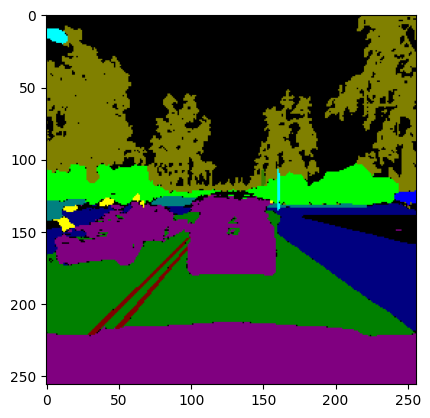

In [ ]:
import requests
from google.colab import files

# Diperbaiki: upload gambar test langsung lewat dialog Colab, tidak lagi
# bergantung pada path dataset yang mungkin sudah hilang setelah runtime restart.
uploaded = files.upload()  # pilih 1 gambar dari komputer kamu
test_filename = next(iter(uploaded))

with open(test_filename, 'rb') as f:
    response = requests.post(f"{public_url.public_url}/segment-image/", files={'file': f})

result = response.json()

mask_bytes = base64.b64decode(result['segmented_image_base64'])
mask_image = Image.open(io.BytesIO(mask_bytes))
plt.imshow(mask_image)
plt.show()

In [ ]:
str(public_url)

'NgrokTunnel: "https://9b94-34-75-25-137.ngrok-free.app" -> "http://localhost:8000"'

---

Materi: rubythalib.ai — AI Super Class (Computer Vision, Sesi 4: Semantic Segmentation).
Mentor: Daniel Syahputra.